> **Prerequisite:** Run earlier notebooks in numeric order in the **same kernel session**.

# 03 — Main figure

Build and export the composite figure (PDF, PNG, SVG, EPS → `../figures/`).

In [1]:
"""Main figure assembly and export."""
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import pandas as pd


def _resolve_package_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data" / "analysis_input.csv").is_file():
            return candidate
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
        nested = candidate / "mediate_moderate_lesion_analysis"
        if (nested / "data").is_dir() and (nested / "notebooks").is_dir():
            return nested
    if start.name == "notebooks" and (start.parent / "data").is_dir():
        return start.parent
    raise FileNotFoundError(
        "Could not locate mediate_moderate_lesion_analysis package root "
        f"(started search from: {start})"
    )


NOTEBOOK_DIR = Path.cwd()
MEDIATE_MODERATE_LESION_ROOT = _resolve_package_root()
DATA_DIR = MEDIATE_MODERATE_LESION_ROOT / "data"
FIGURES_DIR = MEDIATE_MODERATE_LESION_ROOT / "figures"
OUT_DIR = FIGURES_DIR
OUT_BASENAME = "salience_topology_mediation"


def _exec_notebook_code(nb_name: str) -> None:
    nb_dir = NOTEBOOK_DIR if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR / "notebooks"
    nb_path = nb_dir / nb_name
    if not nb_path.is_file():
        raise RuntimeError(
            f"Missing prerequisite notebook: {nb_path}. "
            f"Run earlier notebooks in numeric order first."
        )
    nb = json.loads(nb_path.read_text(encoding="utf-8"))
    for cell in nb["cells"]:
        if cell["cell_type"] != "code":
            continue
        src = "".join(cell["source"])
        lines = [ln for ln in src.splitlines() if not ln.strip().startswith("%")]
        code = "\n".join(lines).strip()
        if not code:
            continue
        exec(compile(code, nb_name, "exec"), globals())


def _ensure_prerequisites() -> None:
    """Load 01/02 when this notebook runs without prior cells in the same kernel."""
    if "fit_ols_network_pc" in globals() and "panel_a" in globals():
        return
    for nb_name in ("01_statistics.ipynb", "02_panel_plotting.ipynb"):
        _exec_notebook_code(nb_name)


_ensure_prerequisites()

def build_figure(df: pd.DataFrame) -> plt.Figure:
    pc_model = fit_ols_network_pc(df)
    med = fit_moderated_mediation(df)
    lesion = fit_lesion_moderation(df)
    w_in = WIDTH_MM / 25.4
    h_in = HEIGHT_MM / 25.4
    fig = plt.figure(figsize=(w_in, h_in), facecolor="none", dpi=DPI)
    fig.patch.set_alpha(0.0)
    gs = gridspec.GridSpec(
        2,
        2,
        figure=fig,
        wspace=LAYOUT["wspace"],
        hspace=LAYOUT["hspace"],
        width_ratios=[1.0, LAYOUT["gs_col_ratio_right"]],
    )
    gs_a = gs[0, 0]
    gs_b = gridspec.GridSpecFromSubplotSpec(
        1,
        2,
        subplot_spec=gs[0, 1],
        width_ratios=[LAYOUT["gs_b_ratio_left"], LAYOUT["gs_b_ratio_right"]],
        wspace=LAYOUT["gs_b_wspace"],
    )
    gs_heat = gridspec.GridSpecFromSubplotSpec(
        2,
        1,
        subplot_spec=gs_b[0, 0],
        hspace=LAYOUT["gs_heat_hspace"],
    )
    ax_a = fig.add_subplot(gs_a)
    ax_htop = fig.add_subplot(gs_heat[0, 0])
    ax_hbot = fig.add_subplot(gs_heat[1, 0])
    ax_bforest = fig.add_subplot(gs_b[0, 1])
    panel_a(ax_a, pc_model)
    panel_b(ax_htop, ax_hbot, ax_bforest, df)
    ax_c = fig.add_subplot(gs[1, 0])
    ax_d = fig.add_subplot(gs[1, 1])
    panel_c(ax_c, lesion)
    fig.subplots_adjust(
        top=LAYOUT["adj_top"],
        bottom=LAYOUT["adj_bottom"],
        left=LAYOUT["adj_left"],
        right=LAYOUT["adj_right"],
    )
    _nudge_axes_positions([ax_htop, ax_hbot, ax_d], dx=-LAYOUT["bd_shift_left"])
    _nudge_axes_positions(
        [ax_htop, ax_hbot],
        dx=-LAYOUT["heat_shift_left"] + LAYOUT["heat_shift_right"],
    )
    _nudge_axes_positions([ax_bforest], dx=-LAYOUT["bd_shift_left"] * 0.35 - LAYOUT["forest_shift_left"])
    _scale_axes(
        [ax_htop, ax_hbot],
        LAYOUT["heat_scale"],
        dy=LAYOUT["heat_shift_up"] - LAYOUT["heat_nudge_down"],
    )
    _nudge_axes_positions([ax_htop], dy=LAYOUT["heat_top_extra_up"])
    _nudge_axes_positions(
        [ax_hbot],
        dy=-LAYOUT["heat_bottom_shift_down"] - LAYOUT["heat_bottom_extra_down"],
    )
    _widen_axes(ax_d, LAYOUT["d_axes_width_scale"], dx=-0.01)
    _match_forest_axes_to_a(ax_a, ax_bforest)
    _stretch_axes_height(
        [ax_a, ax_bforest],
        LAYOUT["ad_forest_height_scale"],
    )
    _add_forest_xlabel(fig, ax_bforest, ax_a)
    _nudge_heatmaps_to_forest_xlabel(fig, [ax_htop, ax_hbot], ax_hbot, ax_a)
    fig.canvas.draw()
    d_content_dx = _d_content_dx_aligned_to_b_heat_yticklabels(
        fig, ax_d, ax_htop, ax_hbot
    )
    panel_d(ax_d, med, content_dx=d_content_dx)
    _align_d_footnotes_bottom_to_c_xlabel(
        fig, ax_c, ax_d, line_dy=LAYOUT["d_note_line_dy"]
    )
    _place_panel_labels(fig, ax_a, ax_htop, ax_c, ax_d, d_content_dx=d_content_dx)
    return fig


def _crop_rgba_tight_with_border(
    im,
    *,
    alpha_thresh: int = FIG_SAVE_ALPHA_THRESH,
    border_px: int = FIG_SAVE_BORDER_PX,
):
    """Tight-crop on all sides, then pad each edge with transparent margin."""
    from PIL import Image

    arr = np.asarray(im.convert("RGBA"), dtype=np.uint8)
    alpha = arr[:, :, 3]
    ys, xs = np.nonzero(alpha > alpha_thresh)
    if xs.size == 0:
        return Image.fromarray(arr, mode="RGBA"), 0
    c0, c1 = int(xs.min()), int(xs.max())
    r0, r1 = int(ys.min()), int(ys.max())
    tight = arr[r0 : r1 + 1, c0 : c1 + 1].copy()
    th, tw = tight.shape[:2]
    bp = max(1, int(border_px))
    out = np.zeros((th + 2 * bp, tw + 2 * bp, 4), dtype=np.uint8)
    out[:, :, 3] = 0
    out[bp : bp + th, bp : bp + tw] = tight
    return Image.fromarray(out, mode="RGBA"), bp


def _save_figure_cropped(
    fig: plt.Figure,
    path: Path,
    *,
    dpi: int | None = None,
) -> tuple[Path, tuple[int, int], tuple[int, int]]:
    """Raster export with bottom/right crop (PNG/PDF); SVG uses tight bbox."""
    import io
    from datetime import datetime

    from PIL import Image

    export_dpi = int(dpi if dpi is not None else fig.dpi)
    fig.canvas.draw()
    ext = path.suffix.lower()
    pad_in = FIG_SAVE_BORDER_PX / float(export_dpi)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    def _alt(p: Path) -> Path:
        return p.with_name(f"{p.stem}_{stamp}{p.suffix}")

    if ext in (".svg", ".eps"):
        try:
            fig.savefig(
                path,
                format=ext.lstrip("."),
                dpi=export_dpi,
                bbox_inches="tight",
                pad_inches=pad_in,
                transparent=True,
                facecolor="none",
                edgecolor="none",
            )
        except PermissionError:
            path = _alt(path)
            fig.savefig(
                path,
                format=ext.lstrip("."),
                dpi=export_dpi,
                bbox_inches="tight",
                pad_inches=pad_in,
                transparent=True,
                facecolor="none",
                edgecolor="none",
            )
        print(f"Saved: {path} ({ext.upper()} tight bbox, dpi={export_dpi})")
        return path, (0, 0), (0, 0)

    buf = io.BytesIO()
    try:
        fig.savefig(
            buf,
            format="png",
            dpi=export_dpi,
            bbox_inches=None,
            transparent=True,
            facecolor="none",
            edgecolor="none",
        )
    except Exception:
        raise
    buf.seek(0)
    im_raw = Image.open(buf).convert("RGBA")
    im, bp = _crop_rgba_tight_with_border(im_raw)
    try:
        if ext == ".png":
            im.save(path, format="PNG", dpi=(export_dpi, export_dpi))
        elif ext == ".pdf":
            bg = Image.new("RGB", im.size, (255, 255, 255))
            bg.paste(im, mask=im.split()[3])
            bg.save(path, format="PDF", resolution=float(export_dpi))
        else:
            im.save(path, dpi=(export_dpi, export_dpi))
    except PermissionError:
        path = _alt(path)
        if ext == ".png":
            im.save(path, format="PNG", dpi=(export_dpi, export_dpi))
        elif ext == ".pdf":
            bg = Image.new("RGB", im.size, (255, 255, 255))
            bg.paste(im, mask=im.split()[3])
            bg.save(path, format="PDF", resolution=float(export_dpi))
        else:
            im.save(path, dpi=(export_dpi, export_dpi))
    dw, dh = im.size[0] - im_raw.size[0], im.size[1] - im_raw.size[1]
    print(
        f"Saved: {path} ({im_raw.size[0]}x{im_raw.size[1]} -> {im.size[0]}x{im.size[1]} px, "
        f"dpi={export_dpi}, tight crop all sides border={bp}px, Δ={dw}x{dh})"
    )
    return path, im_raw.size, im.size


def save_figure_exports(
    fig,
    out_dir: Path,
    stem: str = "salience_topology_mediation",
    *,
    dpi: int | None = None,
) -> list[Path]:
    out_dir.mkdir(parents=True, exist_ok=True)
    saved: list[Path] = []
    for ext in ("pdf", "png", "svg", "eps"):
        path, _, _ = _save_figure_cropped(fig, out_dir / f"{stem}.{ext}", dpi=dpi)
        saved.append(path)
    return saved


BUILD_VERSION = "v1.0.0"


def main(*, show: bool | None = None, export: bool | None = None) -> plt.Figure:
    if show is None:
        show = _in_notebook()
    if export is None:
        export = not _in_notebook()
    if show:
        _enable_inline_backend()
    print(f"Building figure ({BUILD_VERSION}, CD_GREEN={CD_GREEN}) ...")
    df = load_analysis_df()
    fig = build_figure(df)
    if export:
        save_figure_exports(fig, OUT_DIR, stem="salience_topology_mediation")
    if show:
        _show_figure(fig)
    elif not export:
        plt.close(fig)
    return fig


Rows: 43 | Subjects: 43


Saved: D:\文件同步\文件\数据分析结果\data_code_figure\mediate_moderate_lesion\figures\salience_topology_mediation.pdf (5905x4299 -> 5615x3799 px, dpi=600, tight crop all sides border=3px, Δ=-290x-500)


Saved: D:\文件同步\文件\数据分析结果\data_code_figure\mediate_moderate_lesion\figures\salience_topology_mediation.png (5905x4299 -> 5615x3799 px, dpi=600, tight crop all sides border=3px, Δ=-290x-500)


Saved: D:\文件同步\文件\数据分析结果\data_code_figure\mediate_moderate_lesion\figures\salience_topology_mediation.svg (.SVG tight bbox, dpi=600)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: D:\文件同步\文件\数据分析结果\data_code_figure\mediate_moderate_lesion\figures\salience_topology_mediation.eps (.EPS tight bbox, dpi=600)


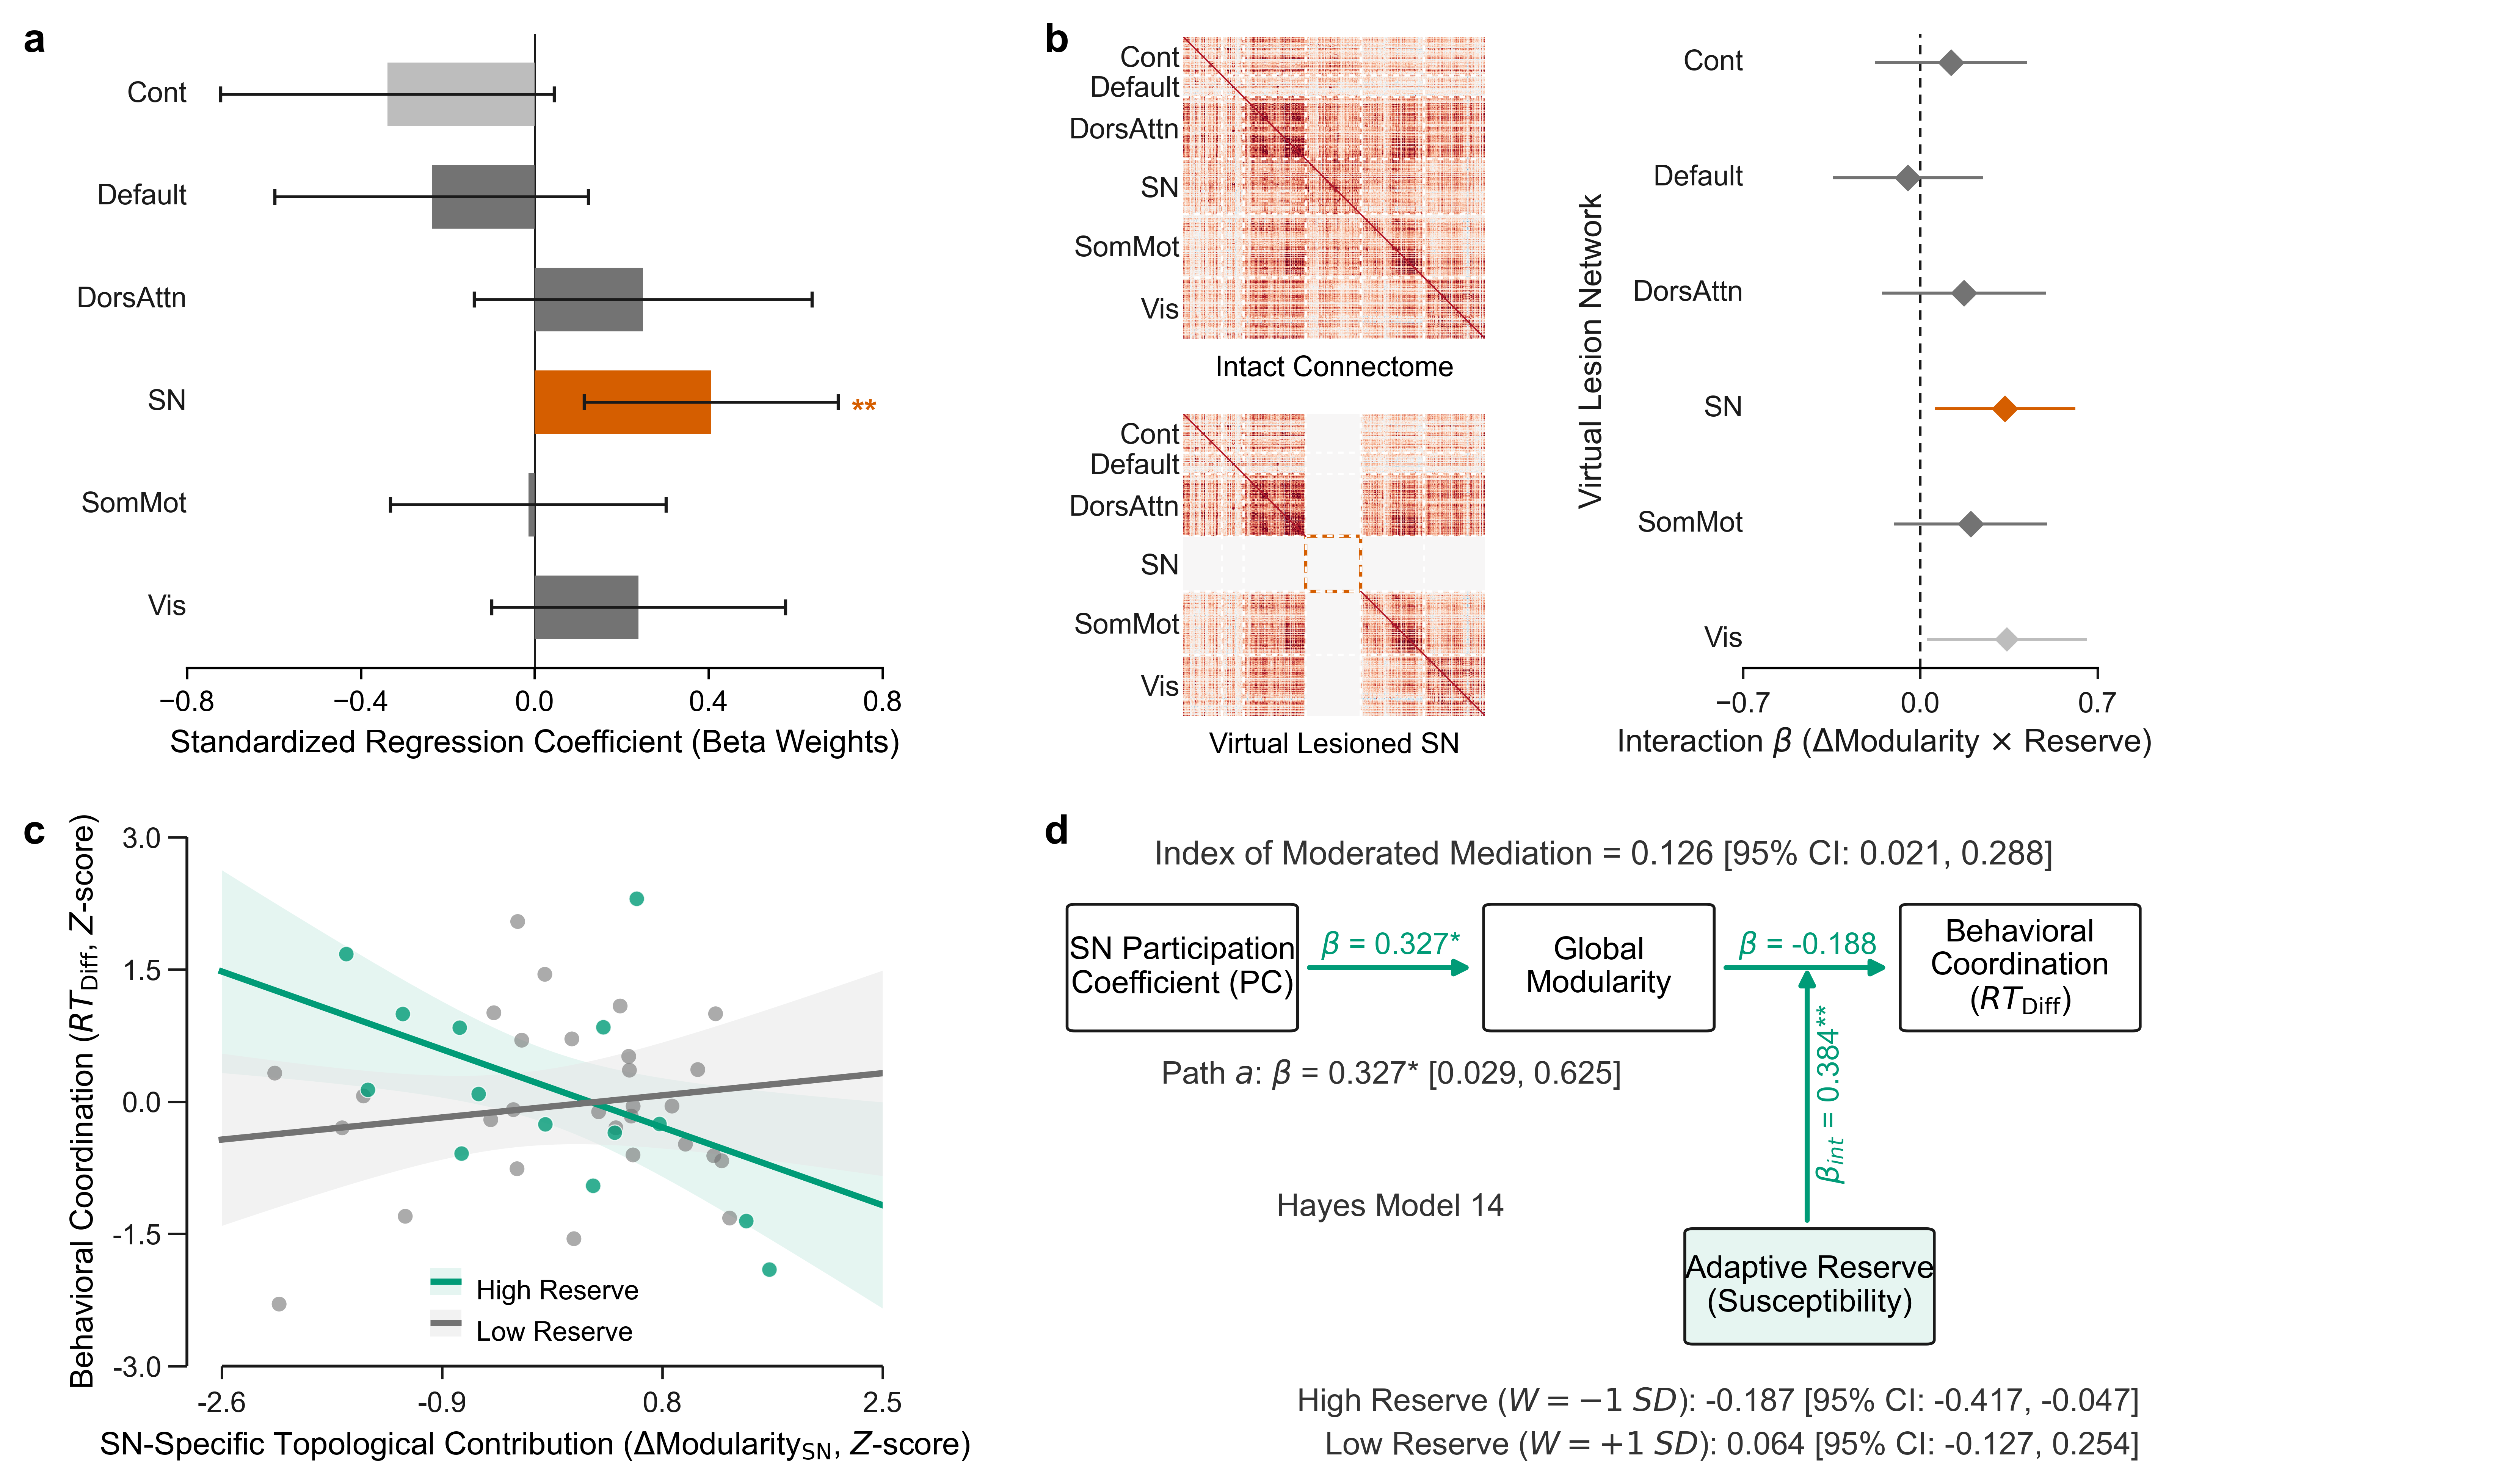

Saved Figure to D:\文件同步\文件\数据分析结果\data_code_figure\mediate_moderate_lesion\figures\salience_topology_mediation.pdf (v1.0.0)


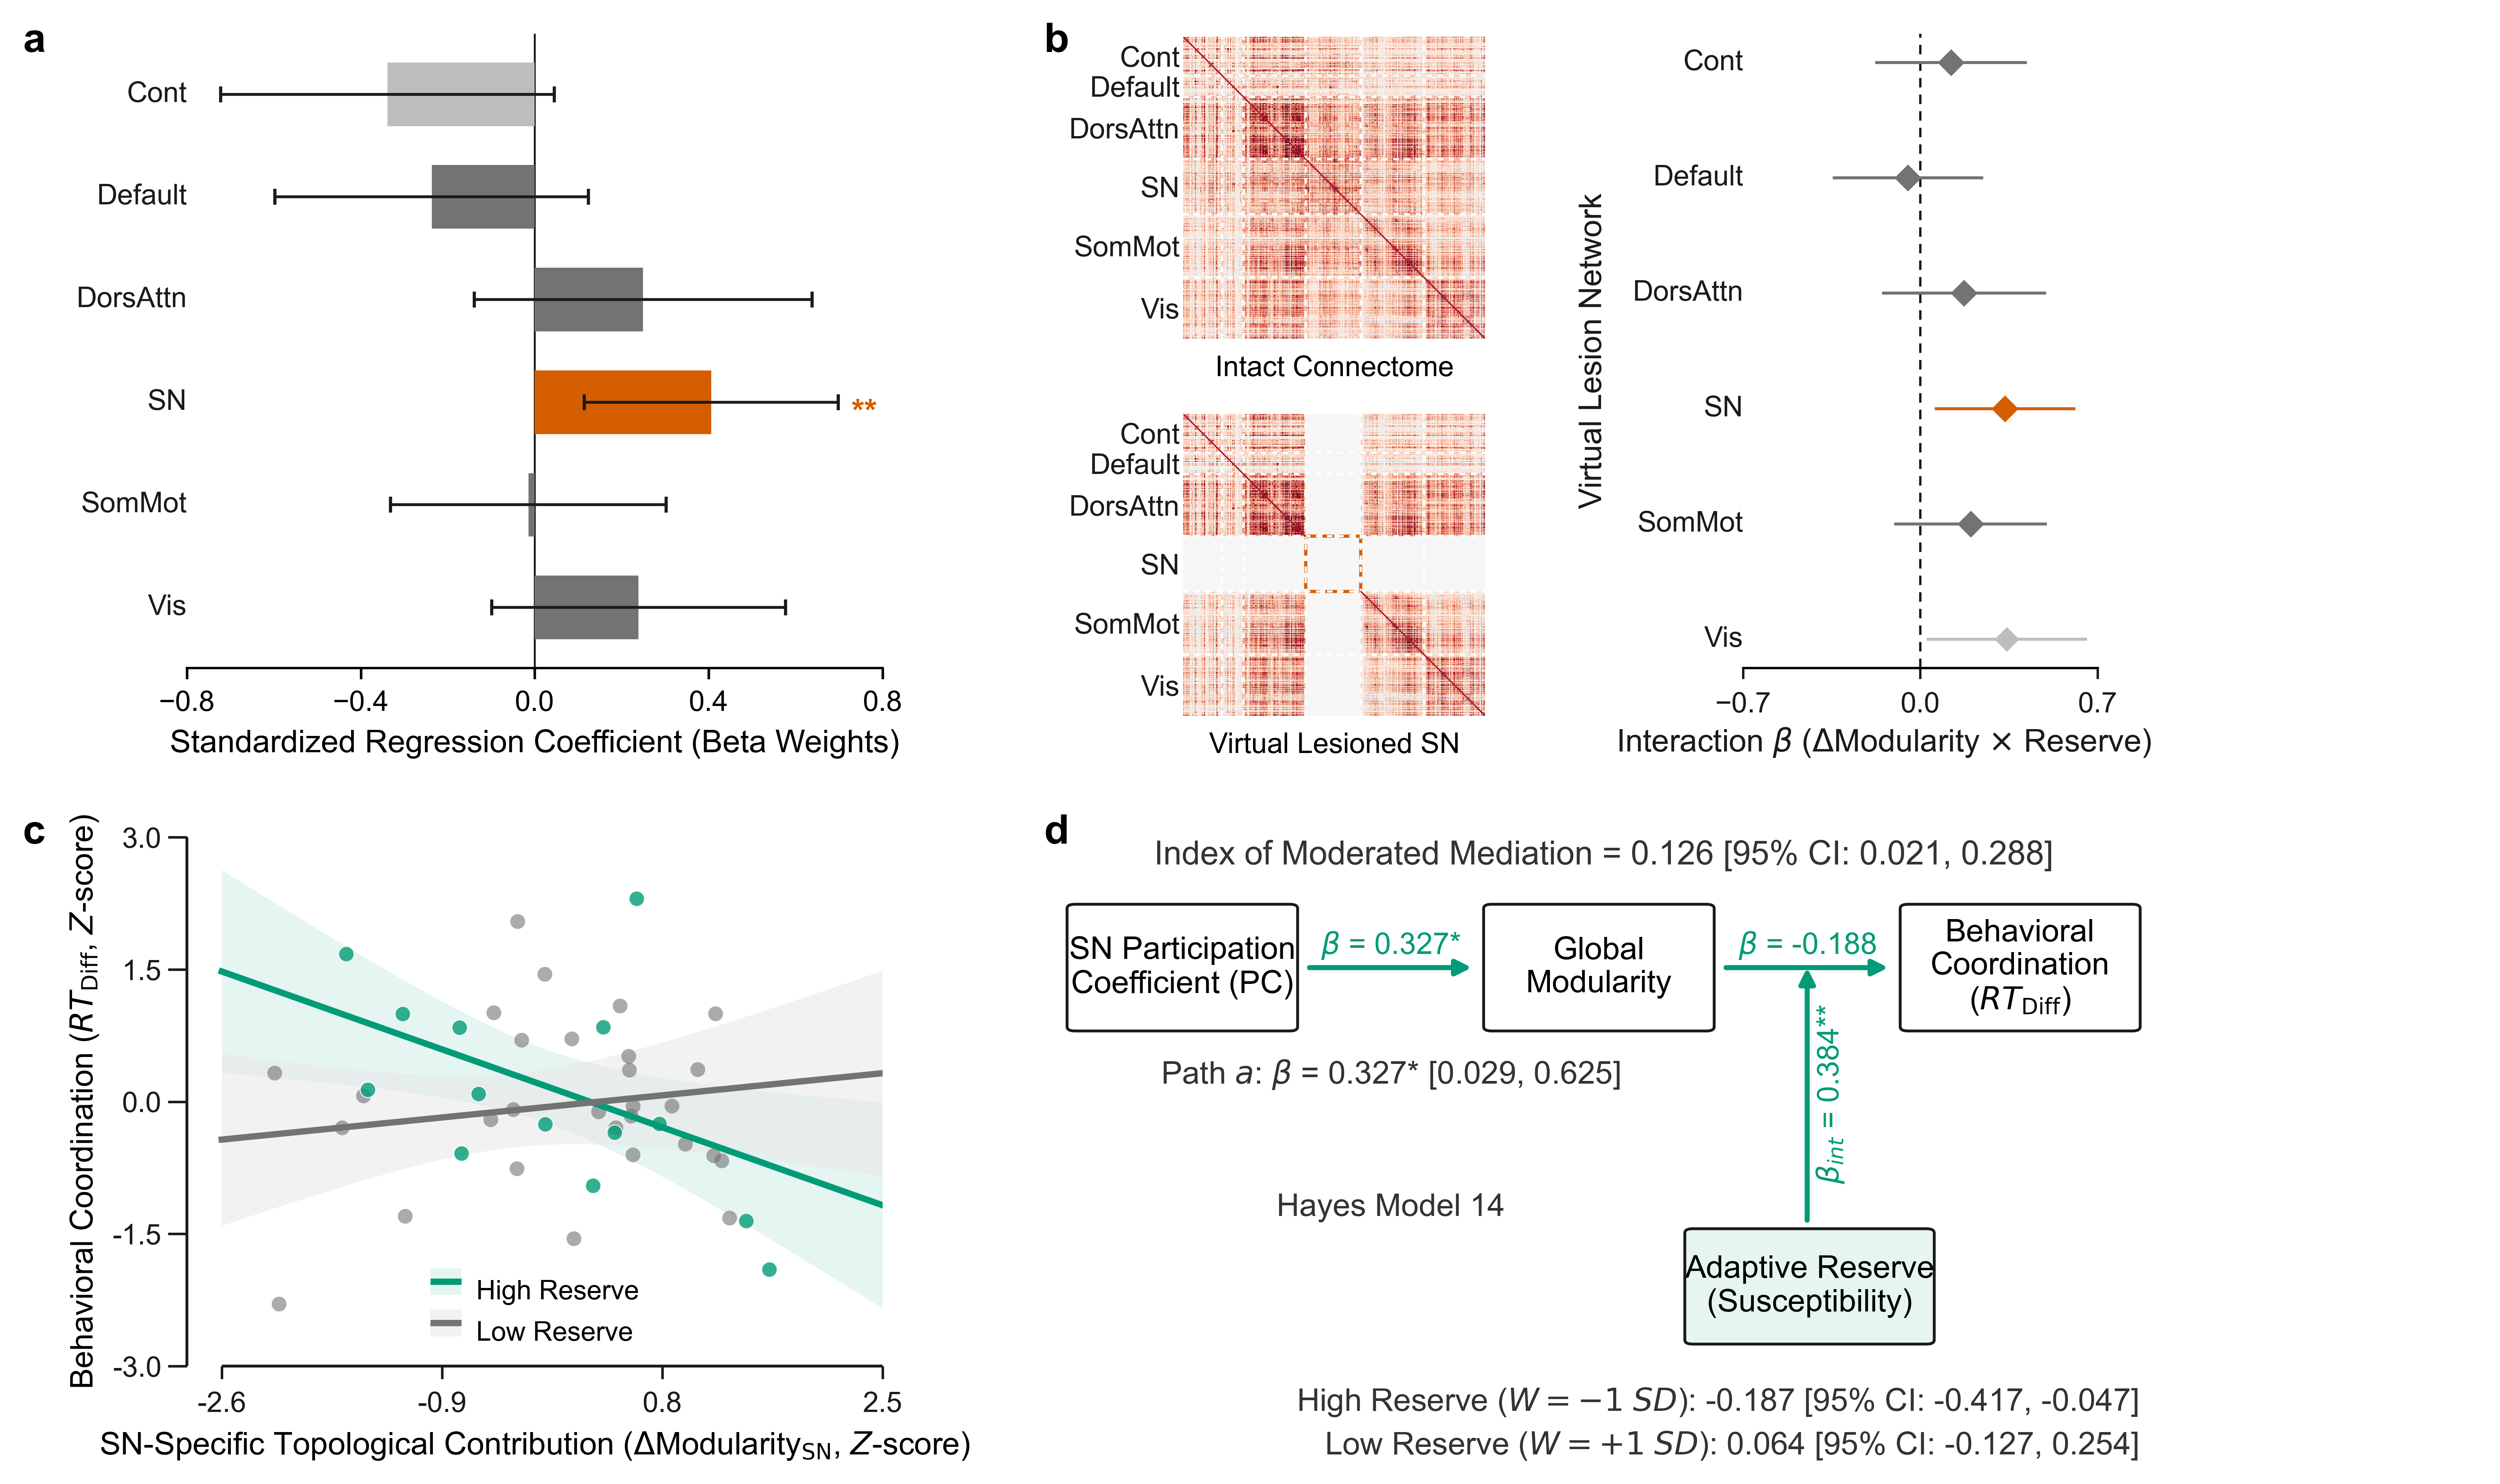

In [2]:
%matplotlib inline

df = load_analysis_df()
fig = build_figure(df)
save_figure_exports(fig, OUT_DIR, stem=OUT_BASENAME)
_enable_inline_backend()
_show_figure(fig)
print(f"Saved Figure to {OUT_DIR / OUT_BASENAME}.pdf ({BUILD_VERSION})")